In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

print("Week 3: Gradient Descent")

Week 3: Gradient Descent


In [76]:
df = pd.read_csv('/content/placement_predict_50k.csv')

print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (50000, 31)
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly']


In [77]:
df = df.drop(columns=['IsAnomaly'], errors='ignore')

df = df.select_dtypes(include=np.number)

print("Numerical columns:")
print(df.columns.tolist())

Numerical columns:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'PlacementStatus']


In [78]:
X = df.drop(columns=['CGPA'])
y = df['CGPA']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 20)
y shape: (50000,)


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 20)
Testing data: (10000, 20)


In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Feature scaling completed
Training shape: (40000, 20)
Testing shape: (10000, 20)


In [81]:
X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

theta = np.zeros(X_train_b.shape[1])

learning_rate = 0.01
epochs = 1000
batch_losses = []

for epoch in range(epochs):
    predictions = X_train_b @ theta
    error = predictions - y_train.values

    mse = np.mean(error ** 2)
    batch_losses.append(mse)

    gradients = (2 / len(X_train_b)) * (X_train_b.T @ error)
    theta -= learning_rate * gradients

print("Batch Gradient Descent completed")
print("Final MSE:", batch_losses[-1])

Batch Gradient Descent completed
Final MSE: nan


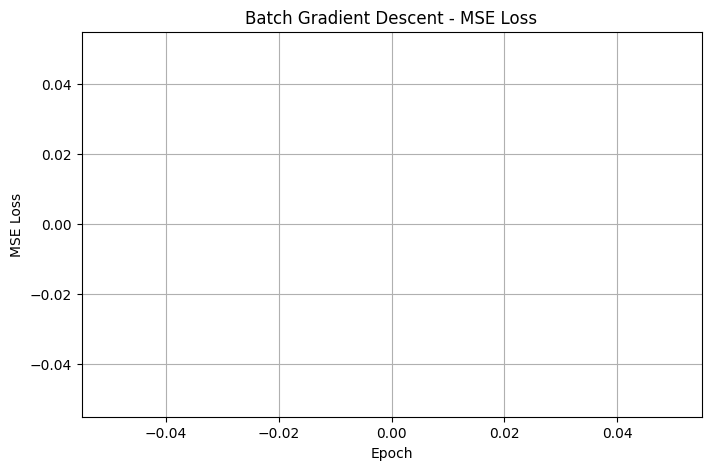

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(batch_losses)

plt.title("Batch Gradient Descent - MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.show()

In [84]:
df = df.drop(columns=['IsAnomaly'], errors='ignore')

df = df.select_dtypes(include=np.number)

df = df.fillna(df.median())

print("Missing values:", df.isnull().sum().sum())
print("Numerical columns:", df.columns.tolist())

Missing values: 0
Numerical columns: ['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'PlacementStatus']
